# FarmTech Solutions — Fase 5: Machine Learning na Cabeça
## Previsão de rendimento de safra e análise de tendências de produtividade

**Grupo — FarmTech Solutions:** Antuny Marques (RM573852) · Tiago Gonçalves (RM570935) ·
Carlos Ribeiro (RM571449) · Lucas Ribeiro (RM572508) · Anderson Sapucaia (RM571668)

**Disciplina:** Fase 5 — Machine Learning na Cabeça (FIAP)

**Repositório:** [github.com/AntunyDev/fiap-ia-farmtech](https://github.com/AntunyDev/fiap-ia-farmtech) ·
**Vídeo demonstrativo:** `[LINK DO YOUTUBE — não listado]`

---

### Índice
1. [Contexto e objetivo](#1)
2. [Carga e limpeza dos dados](#2)
3. [Análise exploratória (EDA)](#3)
4. [Detecção de outliers](#4)
5. [Clusterização e tendências de produtividade](#5)
6. [Modelagem preditiva (5 algoritmos de regressão)](#6)
7. [Conclusão — pontos fortes e limitações](#7)

<a id="1"></a>
## 1. Contexto e objetivo

A **FarmTech Solutions** presta serviços de IA para uma fazenda de médio porte
(~200 hectares) que cultiva diversas culturas simultaneamente. A fazenda coleta,
via sensores, quatro variáveis agrometeorológicas — **precipitação**, **umidade
específica a 2 m**, **umidade relativa a 2 m** e **temperatura a 2 m** — para cada
cultura plantada, junto do **rendimento** (t/ha) observado ao final do ciclo.

**Objetivos deste notebook:**
1. Fazer uma **análise exploratória** dos dados para entender distribuições, relações
   entre variáveis e a qualidade da base;
2. Encontrar **tendências de produtividade** por meio de **clusterização** e identificar
   **cenários discrepantes (outliers)**;
3. Construir e comparar **cinco modelos preditivos** (algoritmos diferentes) capazes de
   estimar o rendimento da safra a partir das condições agrometeorológicas, seguindo boas
   práticas de um projeto de Machine Learning (split treino/teste, pipeline sem vazamento
   de dados, validação cruzada e métricas apropriadas ao problema).

**Base de dados:** `data/crop_yield.csv`, fornecida pela FIAP para esta atividade
(Capítulo 10). O carregamento a seguir usa detecção flexível de nomes de coluna, então
o notebook continua funcionando mesmo que o arquivo oficial seja atualizado com
pequenas variações de cabeçalho.

In [1]:
# ============================================================
# IMPORTAÇÕES E CONFIGURAÇÃO GERAL
# ============================================================
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")  # silencia avisos não-críticos de bibliotecas (ex.: convergência) para um relatório mais limpo
RANDOM_STATE = 42  # semente única usada em todo o notebook, para resultados reprodutíveis
np.random.seed(RANDOM_STATE)

# --- Paleta de cores do relatório (consistente em todos os gráficos) ---
# 8 cores categóricas, ordem fixa (uma cor por cultura, nunca "reciclada" entre gráficos)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
# Rampa sequencial (uma única cor, do claro ao escuro) para grandezas contínuas
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)
# Rampa divergente (azul <-> vermelho, com cinza neutro no meio) para correlações (-1 a +1)
DIV_CMAP = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#f0efec", "#e34948"])
# Cores de status, reservadas para estados (nunca usadas como cor de série categórica)
STATUS = {"bom": "#0ca30c", "atencao": "#fab219", "critico": "#d03b3b"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781", "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}

plt.rcParams.update({
    "figure.facecolor": INK["surface"],
    "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["axis"],
    "axes.labelcolor": INK["primary"],
    "axes.grid": True,
    "grid.color": INK["grid"],
    "grid.linewidth": 0.8,
    "text.color": INK["primary"],
    "xtick.color": INK["secondary"],
    "ytick.color": INK["secondary"],
    "font.size": 10.5,
    "figure.dpi": 100,
})
sns.set_style("white")


def estilizar_eixos(ax):
    """Remove bordas superior/direita e deixa a grade discreta (padrão usado em todo o relatório)."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.6)
    return ax


print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


<a id="2"></a>
## 2. Carga e limpeza dos dados

In [2]:
# Carrega a base de dados bruta
caminho_dados = "data/crop_yield.csv"
df_raw = pd.read_csv(caminho_dados)

print(f"Dimensões do dataset: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
print("\nColunas originais encontradas no arquivo:")
print(df_raw.columns.tolist())
df_raw.head()

Dimensões do dataset: 156 linhas x 6 colunas

Colunas originais encontradas no arquivo:
['Crop', 'Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
def canonizar_colunas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Renomeia as colunas originais para nomes curtos e padronizados, usando
    correspondência por palavras-chave. Funciona tanto se o arquivo oficial do
    portal usar cabeçalhos em inglês (ex.: "Specific Humidity at 2 Meters (g/kg)")
    quanto em português (ex.: "Umidade específica a 2 metros (g/kg)") — o notebook
    fica robusto a pequenas variações no arquivo de origem.
    """
    mapa = {}
    for col in df.columns:
        c = col.strip().lower()
        if "crop" in c or "cultura" in c:
            mapa[col] = "crop"
        elif "precip" in c:
            mapa[col] = "precipitation"
        elif "specific" in c or "específica" in c or "especifica" in c:
            mapa[col] = "specific_humidity"
        elif "relative" in c or "relativa" in c:
            mapa[col] = "relative_humidity"
        elif "temp" in c:
            mapa[col] = "temperature"
        elif "yield" in c or "rendimento" in c:
            mapa[col] = "yield_hg_ha"
        else:
            mapa[col] = col
    return df.rename(columns=mapa)


df = canonizar_colunas(df_raw)
print("Colunas padronizadas:", df.columns.tolist())
print(f"\nCulturas na base: {sorted(df['crop'].unique())}")
print(df["crop"].value_counts())

Colunas padronizadas: ['crop', 'precipitation', 'specific_humidity', 'relative_humidity', 'temperature', 'yield_hg_ha']

Culturas na base: ['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']
crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


**Duas observações importantes sobre a base, antes de seguir:**

1. **Unidade do rendimento.** A coluna `Yield` do arquivo original varia de ~5 mil a
   ~200 mil. Comparando com produtividades agrícolas reais (ex.: óleo de palma
   rende dezenas de t/ha, cacau rende menos de 1 t/ha), esses valores são consistentes
   com **hg/ha (hectogramas por hectare)** — a unidade nativa do FAOSTAT — e não
   "toneladas por hectare" como descrito no enunciado da atividade. Convertendo
   (1 t/ha = 10.000 hg/ha), os números passam a bater exatamente com produtividades
   conhecidas dessas culturas. Por isso, criamos abaixo a coluna `yield_t_ha` já
   convertida, e é ela que usamos em todo o notebook (mantendo a unidade pedida no
   enunciado, de forma tecnicamente correta).
2. **Unidade da precipitação.** A coluna `Precipitation (mm day-1)` varia de ~1900 a
   ~3100. Um valor diário de milhares de mm de chuva é fisicamente impossível (o
   recorde mundial de chuva em 24h é de ~1.800 mm). Esses valores são consistentes com
   **precipitação anual acumulada (mm/ano)** — provavelmente um rótulo de coluna
   herdado do dataset original. Optamos por **manter a coluna como está** (não há um
   fator de conversão certo), mas o nome `precipitation` é tratado, no restante do
   notebook, como "precipitação anual", não diária.

In [4]:
# Conversão de unidade do rendimento: hg/ha -> t/ha (1 t/ha = 10.000 hg/ha)
df["yield_t_ha"] = df["yield_hg_ha"] / 10_000

colunas_numericas = ["precipitation", "specific_humidity", "relative_humidity", "temperature", "yield_t_ha"]
colunas_clima = ["precipitation", "specific_humidity", "relative_humidity", "temperature"]  # sem yield_t_ha: usadas para a clusterização (Seção 5)

df[["crop", "yield_hg_ha", "yield_t_ha"]].groupby("crop").mean(numeric_only=True).round(2)

,yield_hg_ha,yield_t_ha
crop,,
"Cocoa, beans",8883.13,0.89
Oil palm fruit,175804.69,17.58
"Rice, paddy",32099.67,3.21
"Rubber, natural",7824.90,0.78


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crop               156 non-null    str    
 1   precipitation      156 non-null    float64
 2   specific_humidity  156 non-null    float64
 3   relative_humidity  156 non-null    float64
 4   temperature        156 non-null    float64
 5   yield_hg_ha        156 non-null    int64  
 6   yield_t_ha         156 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 10.6 KB


**Leitura inicial:** a base combina uma variável categórica (`crop`, a cultura) com
quatro variáveis agrometeorológicas contínuas e a variável-alvo `yield_t_ha`
(rendimento em toneladas por hectare, já convertido). A seguir, verificamos
qualidade dos dados: valores ausentes, duplicatas e valores fora de faixa plausível.

In [6]:
# Valores ausentes por coluna
ausentes = df.isna().sum()
ausentes_pct = (ausentes / len(df) * 100).round(2)
tabela_ausentes = pd.DataFrame({"ausentes": ausentes, "% do total": ausentes_pct})
print(tabela_ausentes[tabela_ausentes["ausentes"] > 0])

# Duplicatas exatas
n_duplicatas = df.duplicated().sum()
print(f"\nLinhas duplicadas encontradas: {n_duplicatas}")

Empty DataFrame
Columns: [ausentes, % do total]
Index: []

Linhas duplicadas encontradas: 0


In [7]:
# --- Limpeza ---
# 1) Remove duplicatas exatas
df = df.drop_duplicates().reset_index(drop=True)

# 2) Imputa valores ausentes pela MEDIANA de cada coluna numérica, agrupando por cultura
#    (a mediana por cultura preserva melhor o perfil climático típico de cada cultura
#    do que usar a mediana global do dataset)
for col in colunas_numericas:
    if df[col].isna().any():
        df[col] = df.groupby("crop")[col].transform(lambda s: s.fillna(s.median()))

# 3) Padroniza o texto da coluna categórica (remove espaços extras, capitalização)
df["crop"] = df["crop"].astype(str).str.strip().str.title()

# 4) Garante que não há valores fisicamente inválidos (negativos em variáveis que não podem ser negativas)
for col in ["precipitation", "specific_humidity", "relative_humidity", "yield_t_ha"]:
    n_invalidos = (df[col] < 0).sum()
    if n_invalidos:
        print(f"Aviso: {n_invalidos} valores negativos em '{col}' — removendo linhas.")
        df = df[df[col] >= 0]

df = df.reset_index(drop=True)
print(f"Dataset após limpeza: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Culturas presentes: {sorted(df['crop'].unique())}")

# Mapa fixo cultura -> cor (mesma cor para a mesma cultura em todos os gráficos do notebook).
# Usamos um subconjunto de 4 cores da paleta (azul/laranja/água/verde) validado para
# comparação "todos-contra-todos" (ex.: linhas sobrepostas no mesmo gráfico) — o 4º slot
# padrão da paleta (amarelo) fica reservado para não colidir com o laranja nesse cenário.
CULTURAS = sorted(df["crop"].unique())
CATEGORICAL_TODOS_CONTRA_TODOS = [CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2], CATEGORICAL[5]]
COR_CULTURA = {cultura: CATEGORICAL_TODOS_CONTRA_TODOS[i % 4] for i, cultura in enumerate(CULTURAS)}

Dataset após limpeza: 156 linhas x 7 colunas
Culturas presentes: ['Cocoa, Beans', 'Oil Palm Fruit', 'Rice, Paddy', 'Rubber, Natural']


---
<a id="3"></a>
## 3. Análise exploratória (EDA)

In [8]:
df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation,156.0,2486.498974,289.457914,1934.6200,2302.990000,2424.5500,2718.080000,3085.7900
specific_humidity,156.0,18.203077,0.293923,17.5400,18.030000,18.2700,18.400000,18.7000
relative_humidity,156.0,84.737692,0.996226,82.1100,84.120000,84.8500,85.510000,86.1000
temperature,156.0,26.183590,0.261050,25.5600,26.020000,26.1300,26.300000,26.8100
yield_t_ha,156.0,5.615310,7.042196,0.5249,0.832775,1.8871,6.751875,20.3399


**Estatísticas descritivas:** o desvio-padrão do rendimento (`yield_t_ha`) é
proporcionalmente muito maior do que o das variáveis climáticas — esperado, já que
culturas diferentes (ex.: dendê/óleo de palma vs. cacau) operam em escalas de
rendimento completamente distintas (dezenas de t/ha vs. menos de 1,5 t/ha). Isso
reforça que `crop` precisa ser considerada como variável explicativa nos modelos
(Seção 6), e não apenas como um rótulo.

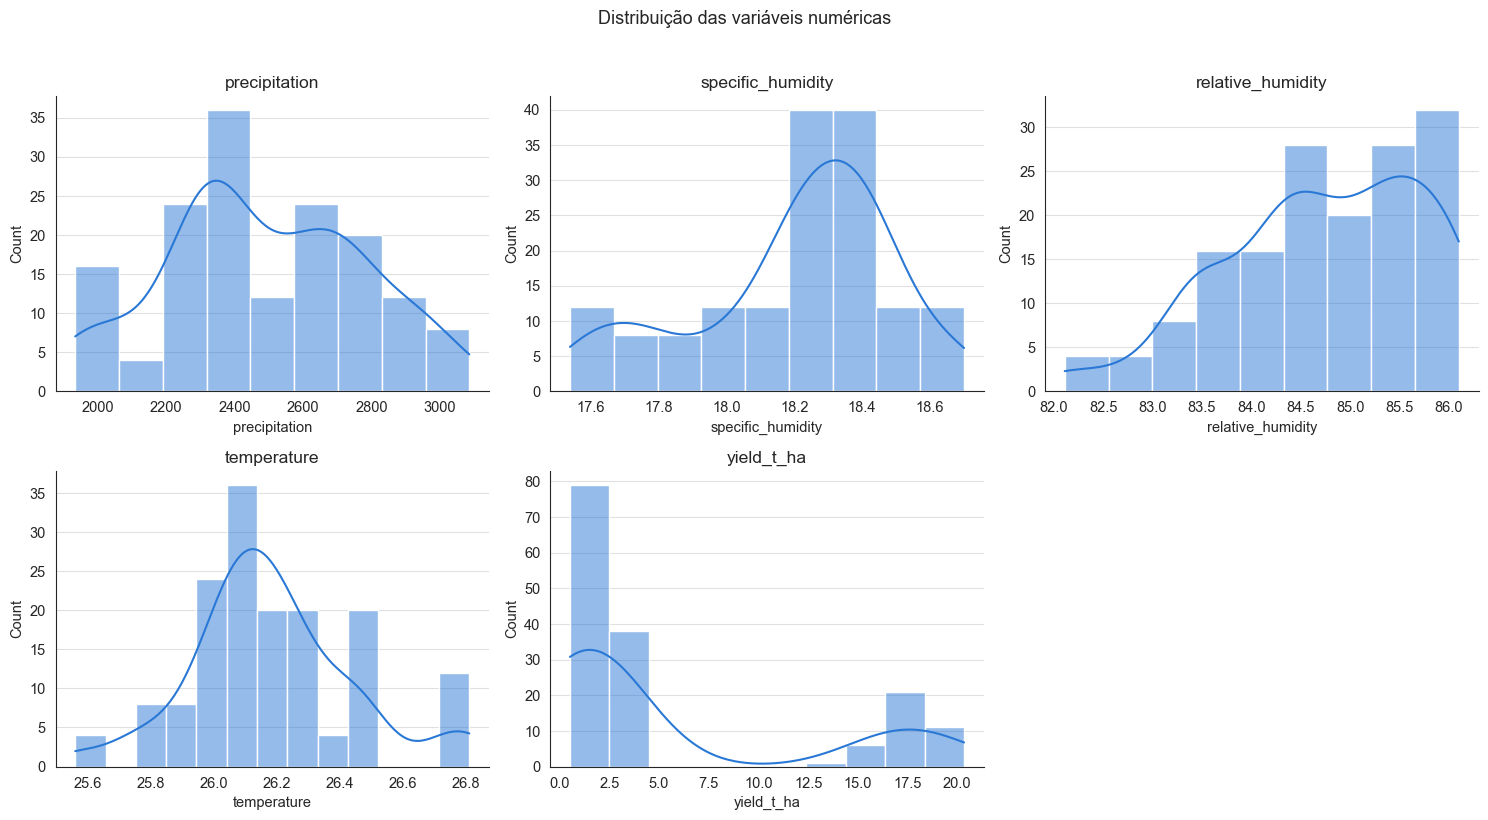

In [9]:
# Distribuição de cada variável numérica (histograma + KDE)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(colunas_numericas):
    sns.histplot(df[col], kde=True, ax=axes[i], color=CATEGORICAL[0], edgecolor="white")
    axes[i].set_title(col)
    estilizar_eixos(axes[i])
axes[-1].axis("off")  # último subplot sobra vazio (5 variáveis em grade 2x3)
fig.suptitle("Distribuição das variáveis numéricas", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

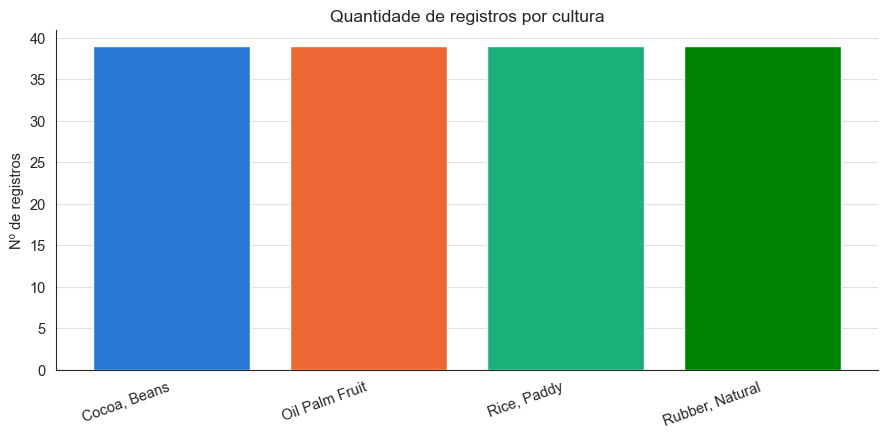

In [10]:
# Quantidade de registros por cultura
contagem = df["crop"].value_counts().loc[CULTURAS]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(contagem.index, contagem.values, color=[COR_CULTURA[c] for c in contagem.index])
ax.set_ylabel("Nº de registros")
ax.set_title("Quantidade de registros por cultura")
estilizar_eixos(ax)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

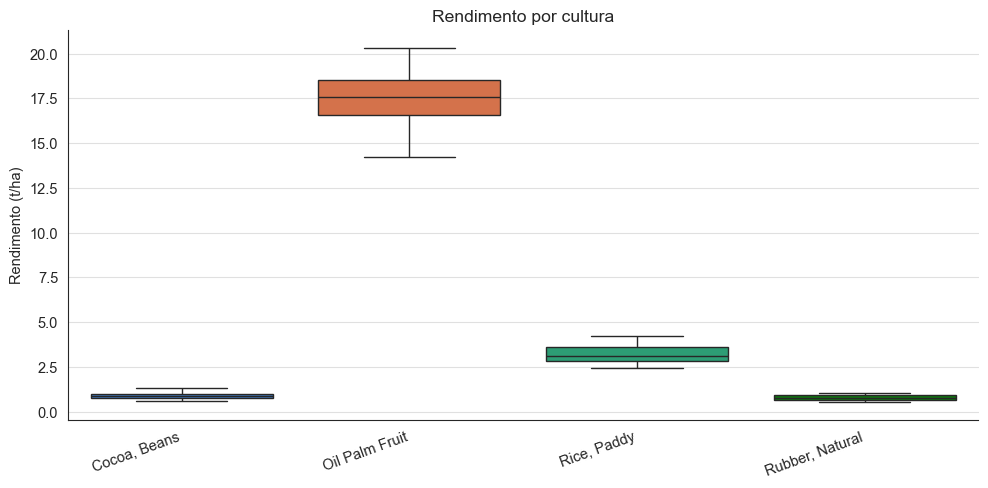

In [11]:
# Rendimento por cultura (boxplot) — cada cultura tem escala própria de rendimento
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x="crop", y="yield_t_ha", order=CULTURAS,
    hue="crop", legend=False, palette=COR_CULTURA, ax=ax,
)
ax.set_ylabel("Rendimento (t/ha)")
ax.set_xlabel("")
ax.set_title("Rendimento por cultura")
estilizar_eixos(ax)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

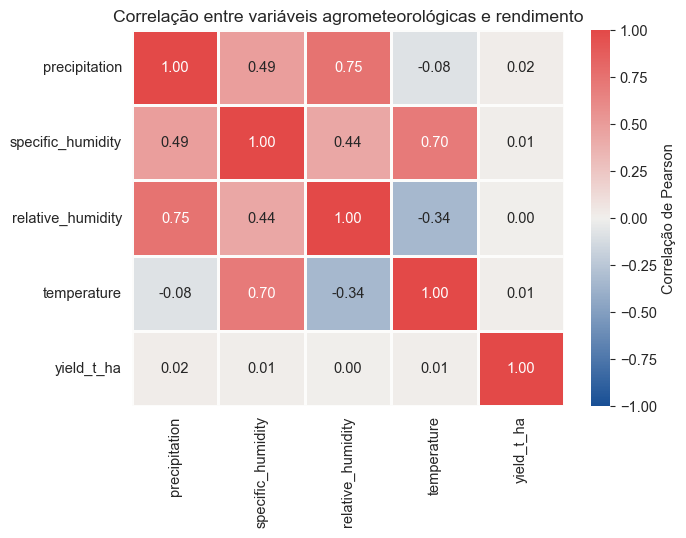

In [12]:
# Mapa de correlação entre as variáveis numéricas (paleta divergente: azul<->vermelho, neutro no meio)
corr = df[colunas_numericas].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=DIV_CMAP, center=0, vmin=-1, vmax=1,
    linewidths=1, linecolor=INK["surface"], cbar_kws={"label": "Correlação de Pearson"}, ax=ax,
)
ax.set_title("Correlação entre variáveis agrometeorológicas e rendimento")
plt.tight_layout()
plt.show()

**Cuidado com a correlação acima:** ela mistura as 4 culturas, que têm escalas de
rendimento completamente diferentes entre si (dendê ~17 t/ha vs. cacau ~0,9 t/ha).
Quando isso acontece, a correlação linear simples tende a ficar próxima de zero
mesmo que exista uma relação real **dentro** de cada cultura — o efeito da escala
entre culturas "esconde" o efeito do clima dentro de cada cultura. Por isso,
calculamos a seguir a correlação clima x rendimento **separadamente para cada cultura**.

In [13]:
# Correlação entre cada variável climática e o rendimento, calculada dentro de cada cultura
corr_por_cultura = pd.DataFrame({
    cultura: df[df["crop"] == cultura][colunas_clima].corrwith(df[df["crop"] == cultura]["yield_t_ha"])
    for cultura in CULTURAS
}).T.round(2)
corr_por_cultura

,precipitation,specific_humidity,relative_humidity,temperature
"Cocoa, Beans",0.17,-0.05,-0.06,-0.01
Oil Palm Fruit,0.22,0.07,-0.04,0.10
"Rice, Paddy",0.33,0.70,0.15,0.61
"Rubber, Natural",0.10,-0.43,-0.05,-0.41


**Sobre a estrutura da base:** ao inspecionar os valores, notamos que as 4 variáveis
climáticas se repetem **exatamente** entre as culturas na mesma posição de linha
(ex.: a 1ª observação de cada uma das 4 culturas tem a mesma precipitação, umidade e
temperatura). Isso indica que a base é, na prática, uma série de ~39 períodos de clima
(nacional/regional) **replicada para cada cultura**, cada uma com seu próprio
rendimento observado — não há, portanto, 39 fazendas diferentes por cultura, e sim
~39 safras/anos. Reconstruímos abaixo um índice relativo de safra (posição dentro de
cada cultura) só para visualizar a evolução do rendimento ao longo do tempo.

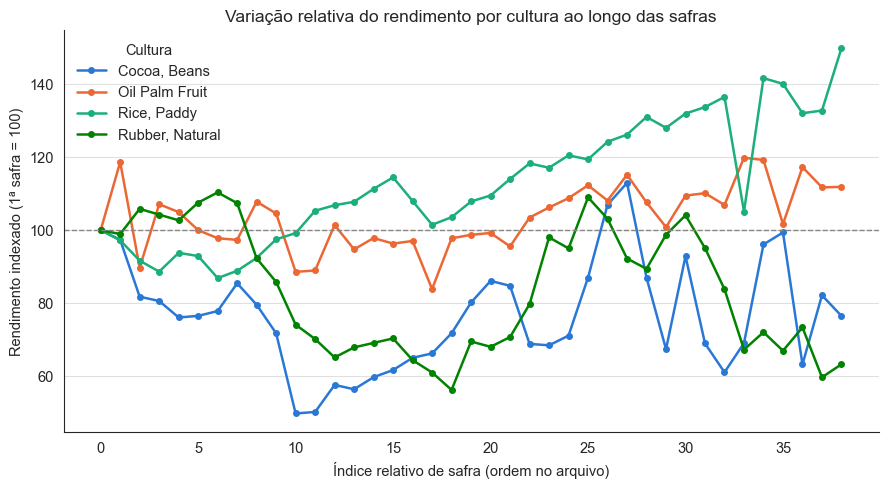

In [14]:
# Índice relativo de safra (0, 1, 2, ...) dentro de cada cultura, na ordem em que aparece no arquivo.
# Como as 4 culturas operam em escalas de rendimento muito diferentes (dendê rende
# dezenas de t/ha; cacau rende menos de 1,5 t/ha), colocá-las em um único eixo em valor
# absoluto esconderia as culturas menores. Por isso, indexamos cada série à sua própria
# primeira safra (= 100) — o gráfico passa a comparar variação relativa, não volume.
df["indice_safra"] = df.groupby("crop").cumcount()

fig, ax = plt.subplots(figsize=(9, 5))
for cultura in CULTURAS:
    sub = df[df["crop"] == cultura].sort_values("indice_safra")
    yield_indexado = sub["yield_t_ha"] / sub["yield_t_ha"].iloc[0] * 100
    ax.plot(sub["indice_safra"], yield_indexado, marker="o", markersize=4, linewidth=1.8,
            color=COR_CULTURA[cultura], label=cultura)
ax.axhline(100, linestyle="--", color=INK["muted"], linewidth=1)
ax.set_xlabel("Índice relativo de safra (ordem no arquivo)")
ax.set_ylabel("Rendimento indexado (1ª safra = 100)")
ax.set_title("Variação relativa do rendimento por cultura ao longo das safras")
estilizar_eixos(ax)
ax.legend(frameon=False, title="Cultura")
plt.tight_layout()
plt.show()

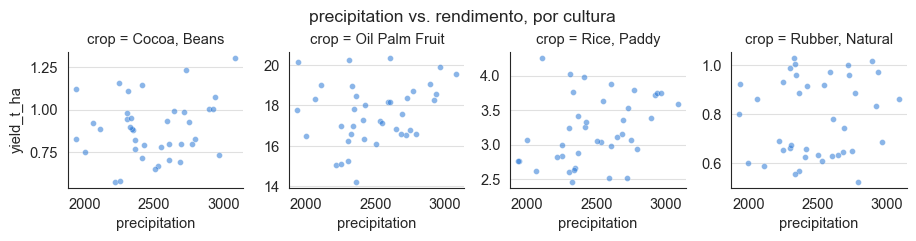

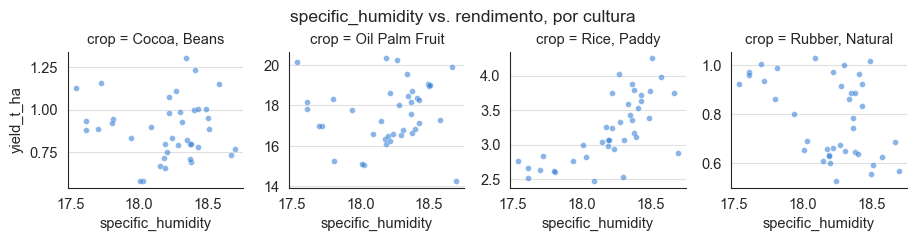

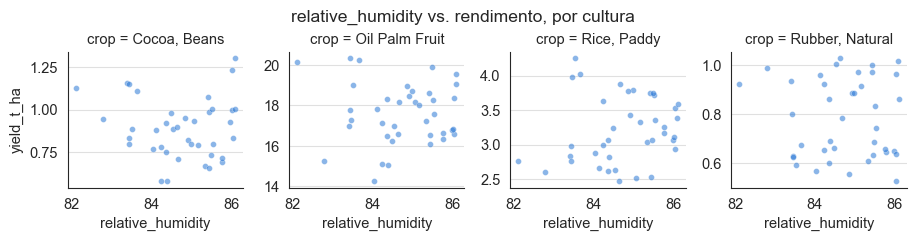

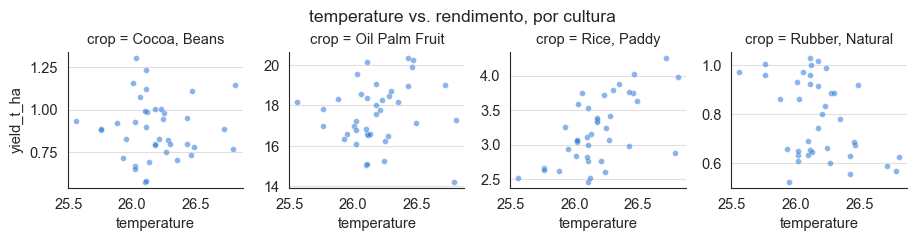

In [15]:
# Relação entre cada variável climática e o rendimento, separada por cultura (small multiples).
# Usar um painel por cultura evita "poluir" um único gráfico com 8 cores simultâneas.
for var in ["precipitation", "specific_humidity", "relative_humidity", "temperature"]:
    g = sns.relplot(
        data=df, x=var, y="yield_t_ha", col="crop", col_wrap=4,
        color=CATEGORICAL[0], s=18, alpha=0.55, height=2.3, facet_kws={"sharex": False, "sharey": False},
    )
    g.figure.suptitle(f"{var} vs. rendimento, por cultura", y=1.03)
    for ax in g.axes.flatten():
        estilizar_eixos(ax)
    plt.show()

**Achados da EDA:**
- As 4 variáveis climáticas variam em uma faixa **estreita** (ex.: temperatura entre
  25,56ºC e 26,81ºC, apenas ~1,25ºC de amplitude) — consistente com ~39 safras de um
  mesmo clima tropical úmido e estável, não um conjunto de regiões/climas variados.
- `specific_humidity` apresenta correlação forte com `temperature` (e moderada com
  `precipitation`) no mapa de calor — fisicamente esperado, já que a umidade
  específica do ar depende da temperatura e da umidade do ambiente.
- A correlação **global** entre clima e rendimento é próxima de zero — mas isso é um
  artefato de misturar culturas de escalas muito diferentes (ver aviso acima). A
  correlação **por cultura** revela um cenário bem mais rico e heterogêneo:
  - `Rice, Paddy` (arroz) é claramente a mais sensível ao clima nesta base (correlação
    de ~0,70 com umidade específica e ~0,61 com temperatura);
  - `Rubber, Natural` (borracha) mostra correlação **negativa** moderada com umidade
    específica e temperatura — rendimento tende a cair quando esses valores sobem;
  - `Cocoa, Beans` e `Oil Palm Fruit` mostram correlação fraca com todas as variáveis
    climáticas nesta amostra — ou seja, dentro da janela climática observada, o clima
    explica pouco da variação de rendimento dessas duas culturas.
- O dendezeiro (óleo de palma) opera em escala de rendimento muito maior (t/ha) que
  cacau, borracha ou arroz — confirma que `crop` precisa entrar como variável
  explicativa forte nos modelos (retomado na Seção 6).
- As 4 variáveis climáticas são **idênticas entre culturas na mesma posição de linha**
  (mesma safra/ano) — ou seja, a base representa o mesmo clima nacional aplicado a
  4 culturas diferentes, não 4 fazendas com climas distintos.

---
<a id="4"></a>
## 4. Detecção de outliers

Cenários discrepantes podem indicar erro de sensor, evento climático extremo (geada,
seca severa) ou quebra de safra por pragas/doenças. Usamos duas abordagens
complementares: (1) a regra estatística do **IQR** por cultura, e (2) o algoritmo
de ensemble **Isolation Forest**, que considera todas as variáveis simultaneamente.

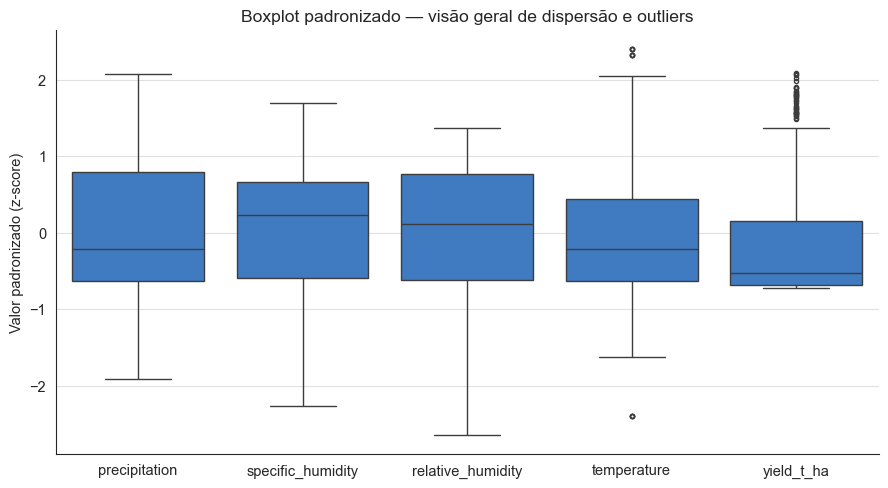

In [16]:
# Boxplots padronizados (z-score) das variáveis numéricas, todas as culturas juntas
df_z = df.copy()
for col in colunas_numericas:
    df_z[col] = (df[col] - df[col].mean()) / df[col].std()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_z[colunas_numericas], ax=ax, color=CATEGORICAL[0], fliersize=3)
ax.set_ylabel("Valor padronizado (z-score)")
ax.set_title("Boxplot padronizado — visão geral de dispersão e outliers")
estilizar_eixos(ax)
plt.tight_layout()
plt.show()

In [17]:
def flags_iqr_por_cultura(df: pd.DataFrame, coluna: str, k: float = 1.5) -> pd.Series:
    """Marca outliers pela regra do IQR (calculada separadamente para cada cultura,
    já que cada uma tem uma faixa de rendimento própria)."""
    flags = pd.Series(False, index=df.index)
    for cultura, grupo in df.groupby("crop"):
        q1, q3 = grupo[coluna].quantile([0.25, 0.75])
        iqr = q3 - q1
        limite_inf, limite_sup = q1 - k * iqr, q3 + k * iqr
        fora = (grupo[coluna] < limite_inf) | (grupo[coluna] > limite_sup)
        flags.loc[grupo.index] = fora
    return flags


df["outlier_iqr_yield"] = flags_iqr_por_cultura(df, "yield_t_ha")
print(f"Outliers de rendimento via IQR (por cultura): {df['outlier_iqr_yield'].sum()} de {len(df)} linhas "
      f"({df['outlier_iqr_yield'].mean() * 100:.1f}%)")

Outliers de rendimento via IQR (por cultura): 0 de 156 linhas (0.0%)


In [18]:
# Isolation Forest: outlier multivariado, considerando as 4 variáveis climáticas + rendimento
iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
df["outlier_isoforest"] = iso.fit_predict(df[colunas_numericas]) == -1
print(f"Outliers via Isolation Forest: {df['outlier_isoforest'].sum()} de {len(df)} linhas "
      f"({df['outlier_isoforest'].mean() * 100:.1f}%)")

# Concordância entre os dois métodos
concordancia = pd.crosstab(df["outlier_iqr_yield"], df["outlier_isoforest"],
                            rownames=["IQR (rendimento)"], colnames=["Isolation Forest"])
print("\nTabela de concordância entre os dois métodos de detecção:")
print(concordancia)

Outliers via Isolation Forest: 5 de 156 linhas (3.2%)

Tabela de concordância entre os dois métodos de detecção:
Isolation Forest  False  True 
IQR (rendimento)              
False               151      5


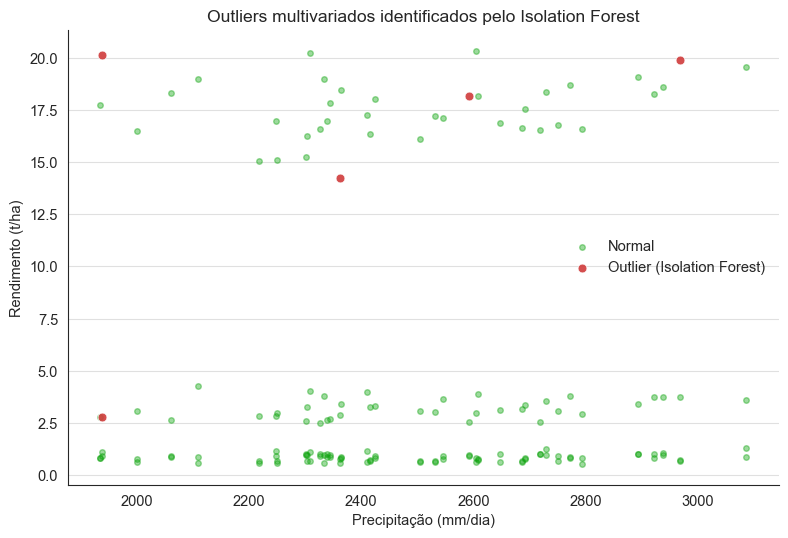

,crop,precipitation,specific_humidity,relative_humidity,temperature,yield_hg_ha,yield_t_ha,indice_safra,outlier_iqr_yield,outlier_isoforest
79,"Rice, Paddy",1938.42,17.54,82.11,26.11,27619,2.7619,1,False,True
56,Oil Palm Fruit,2362.80,18.70,84.03,26.79,142425,14.2425,17,False,True
42,Oil Palm Fruit,2592.35,17.61,85.07,25.56,181826,18.1826,3,False,True
75,Oil Palm Fruit,2967.41,18.67,85.48,26.46,199074,19.9074,36,False,True
40,Oil Palm Fruit,1938.42,17.54,82.11,26.11,201436,20.1436,1,False,True


In [19]:
# Visualização: precipitação x rendimento, destacando os outliers do Isolation Forest
fig, ax = plt.subplots(figsize=(8, 5.5))
normais = df[~df["outlier_isoforest"]]
outliers = df[df["outlier_isoforest"]]
ax.scatter(normais["precipitation"], normais["yield_t_ha"], s=16, alpha=0.4, color=STATUS["bom"], label="Normal")
ax.scatter(outliers["precipitation"], outliers["yield_t_ha"], s=40, alpha=0.9, color=STATUS["critico"],
           edgecolor="white", linewidth=0.5, label="Outlier (Isolation Forest)")
ax.set_xlabel("Precipitação (mm/dia)")
ax.set_ylabel("Rendimento (t/ha)")
ax.set_title("Outliers multivariados identificados pelo Isolation Forest")
estilizar_eixos(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

df[df["outlier_isoforest"]].sort_values("yield_t_ha").head(10)

**Achados sobre outliers:** a regra do IQR **por cultura** não sinalizou nenhum
registro — com apenas 39 observações por cultura e uma base já bastante limpa (sem
valores ausentes/duplicados, Seção 2), os extremos dentro de cada cultura isolada não
são fortes o suficiente para cruzar o limiar de 1,5×IQR. Já o **Isolation Forest**,
que olha as 5 variáveis simultaneamente (e entre culturas), sinalizou ~3% dos
registros — ou seja, encontra combinações **multivariadas** pouco usuais (ex.: uma
combinação específica de clima e rendimento) que a regra univariada por cultura não
captura. Isso ilustra bem por que vale usar mais de um método: cada um enxerga um
tipo diferente de discrepância. Os pontos sinalizados foram **mantidos** no dataset
(não removidos) para as próximas seções, mas ficam identificados — decidir se são
erro de sensor/digitação ou eventos reais depende de validação de campo com o
agrônomo responsável, fora do escopo puramente estatístico deste notebook.

---
<a id="5"></a>
## 5. Clusterização e tendências de produtividade

Nesta seção usamos **aprendizado não supervisionado** para encontrar agrupamentos
naturais de condições agrometeorológicas associadas a diferentes perfis de
rendimento — sem usar o rótulo da cultura, apenas as variáveis contínuas.

**Importante:** o agrupamento usa **somente as 4 variáveis climáticas**
(`precipitation`, `specific_humidity`, `relative_humidity`, `temperature`) — o
`yield_t_ha` é **deixado de fora das features de clusterização** de propósito, e
entra só depois, para *perfilar* cada cluster. Incluir o próprio rendimento entre as
variáveis de agrupamento enviesaria os clusters para simplesmente separar culturas
com escala de rendimento muito diferente (ex.: óleo de palma, na casa de dezenas de
t/ha, vs. as demais culturas, na casa de unidades de t/ha) em vez de revelar
padrões climáticos — o que não corresponde ao objetivo de encontrar tendências de
produtividade a partir do clima.

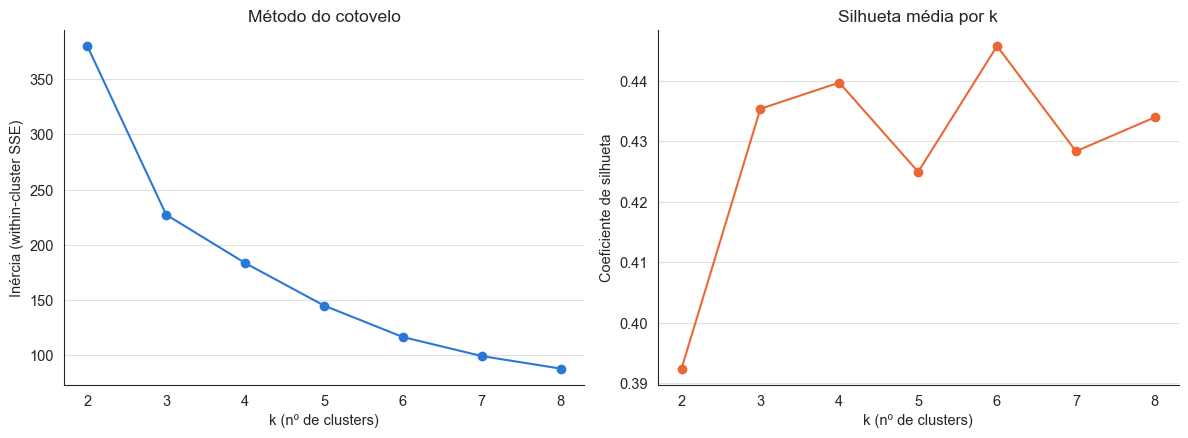

k escolhido (maior silhueta): 6


In [20]:
# Padronização das variáveis climáticas (obrigatória para K-Means e para PCA, que são sensíveis a escala).
# yield_t_ha fica de fora do agrupamento (ver justificativa acima) e é usado só para
# interpretar os clusters depois de formados.
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[colunas_clima])

# Método do cotovelo (inércia) + coeficiente de silhueta, para escolher k
inercias, silhuetas = [], []
faixa_k = range(2, 9)
for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_cluster, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(faixa_k), inercias, marker="o", color=CATEGORICAL[0])
axes[0].set_xlabel("k (nº de clusters)")
axes[0].set_ylabel("Inércia (within-cluster SSE)")
axes[0].set_title("Método do cotovelo")
estilizar_eixos(axes[0])

axes[1].plot(list(faixa_k), silhuetas, marker="o", color=CATEGORICAL[1])
axes[1].set_xlabel("k (nº de clusters)")
axes[1].set_ylabel("Coeficiente de silhueta")
axes[1].set_title("Silhueta média por k")
estilizar_eixos(axes[1])
plt.tight_layout()
plt.show()

k_escolhido = list(faixa_k)[int(np.argmax(silhuetas))]
print(f"k escolhido (maior silhueta): {k_escolhido}")

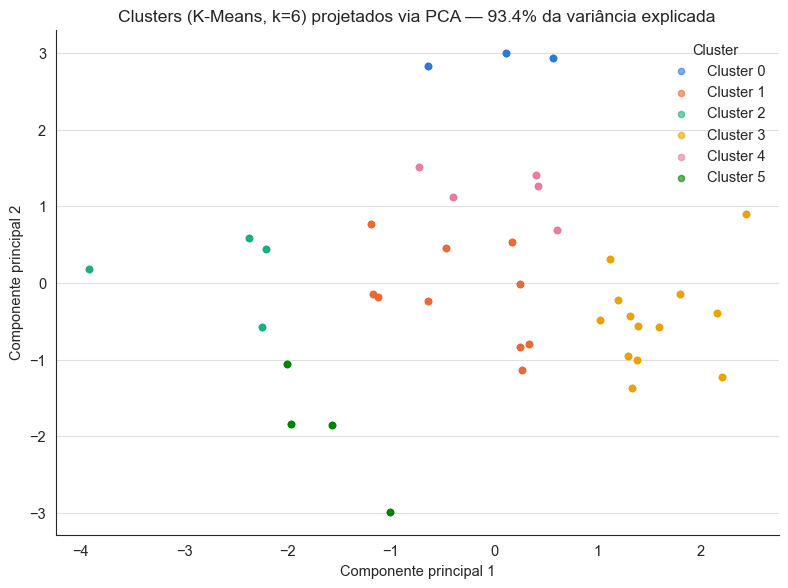

In [21]:
# K-Means final com o k escolhido
kmeans = KMeans(n_clusters=k_escolhido, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster)

# PCA para visualizar os clusters em 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes = pca.fit_transform(X_cluster)
df["pca_1"], df["pca_2"] = componentes[:, 0], componentes[:, 1]
var_explicada = pca.explained_variance_ratio_.sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c]
    ax.scatter(sub["pca_1"], sub["pca_2"], s=20, alpha=0.6, color=CATEGORICAL[c % len(CATEGORICAL)], label=f"Cluster {c}")
ax.set_xlabel(f"Componente principal 1")
ax.set_ylabel(f"Componente principal 2")
ax.set_title(f"Clusters (K-Means, k={k_escolhido}) projetados via PCA — {var_explicada:.1f}% da variância explicada")
estilizar_eixos(ax)
ax.legend(frameon=False, title="Cluster")
plt.tight_layout()
plt.show()

In [22]:
# Perfil de cada cluster: médias das variáveis + rendimento médio
perfil_clusters = df.groupby("cluster")[colunas_numericas].mean().round(2)
perfil_clusters["n_registros"] = df["cluster"].value_counts().sort_index()
perfil_clusters

,precipitation,specific_humidity,relative_humidity,temperature,yield_t_ha,n_registros
cluster,,,,,,
0,2294.09,18.60,83.67,26.77,5.52,12
1,2333.41,18.17,84.87,26.13,5.28,40
2,2105.88,17.75,82.93,26.14,5.55,16
3,2814.98,18.38,85.72,26.14,5.77,52
4,2480.17,18.35,84.17,26.43,6.05,20
5,2334.50,17.68,84.52,25.74,5.57,16


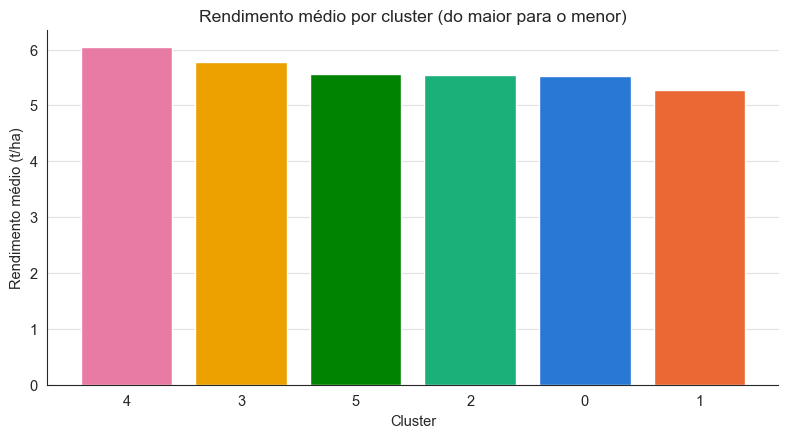

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ordem_clusters = perfil_clusters.sort_values("yield_t_ha", ascending=False).index
cores_cluster = [CATEGORICAL[c % len(CATEGORICAL)] for c in ordem_clusters]
ax.bar(ordem_clusters.astype(str), perfil_clusters.loc[ordem_clusters, "yield_t_ha"], color=cores_cluster)
ax.set_xlabel("Cluster")
ax.set_ylabel("Rendimento médio (t/ha)")
ax.set_title("Rendimento médio por cluster (do maior para o menor)")
estilizar_eixos(ax)
plt.tight_layout()
plt.show()

cluster          0   1  2   3  4  5
crop                               
Cocoa, Beans     3  10  4  13  5  4
Oil Palm Fruit   3  10  4  13  5  4
Rice, Paddy      3  10  4  13  5  4
Rubber, Natural  3  10  4  13  5  4


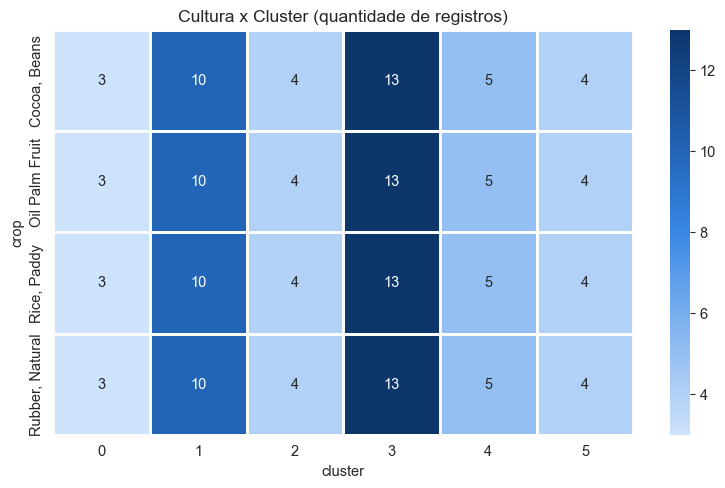

In [24]:
# Os clusters representam perfis climáticos que atravessam culturas, ou coincidem com elas?
crosstab_cluster_cultura = pd.crosstab(df["crop"], df["cluster"])
print(crosstab_cluster_cultura)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(crosstab_cluster_cultura, annot=True, fmt="d", cmap=SEQ_CMAP, linewidths=1, linecolor=INK["surface"], ax=ax)
ax.set_title("Cultura x Cluster (quantidade de registros)")
plt.tight_layout()
plt.show()

In [25]:
# DBSCAN como segunda técnica de clusterização: por natureza, marca pontos de baixa
# densidade como ruído (label -1) — uma forma alternativa, baseada em clusterização,
# de flagar cenários discrepantes, para comparar com o Isolation Forest da Seção 4.
# eps escolhido por busca em grade (valores maiores colapsam tudo em 1 cluster só —
# sinal de que a base não tem "vales" de densidade fortes, coerente com a faixa
# climática estreita observada na EDA).
dbscan = DBSCAN(eps=1.2, min_samples=5)
df["dbscan_label"] = dbscan.fit_predict(X_cluster)
n_ruido = (df["dbscan_label"] == -1).sum()
print(f"DBSCAN: {df['dbscan_label'].nunique() - 1} clusters densos + {n_ruido} pontos classificados como ruído/outlier "
      f"({n_ruido / len(df) * 100:.1f}%)")

concordancia_dbscan = pd.crosstab(df["outlier_isoforest"], df["dbscan_label"] == -1,
                                   rownames=["Outlier (Isolation Forest)"], colnames=["Ruído (DBSCAN)"])
print("\nConcordância DBSCAN x Isolation Forest:")
print(concordancia_dbscan)

DBSCAN: 4 clusters densos + 16 pontos classificados como ruído/outlier (10.3%)

Concordância DBSCAN x Isolation Forest:
Ruído (DBSCAN)              False  True 
Outlier (Isolation Forest)              
False                         139     12
True                            1      4


**Tendências de produtividade identificadas:**
- O método da silhueta aponta o valor de **k impresso acima** (variável `k_escolhido`)
  como a segmentação mais coesa. O mapa de calor Cultura x Cluster mostra um resultado
  marcante: **cada cluster contém exatamente a mesma quantidade das 4 culturas**
  (ex.: se o cluster 3 tem 13 cacaus, ele também tem exatamente 13 dendês, 13 arrozes
  e 13 borrachas). Isso é uma consequência direta da estrutura da base (Seção 3): como
  o clima é idêntico entre culturas na mesma safra, o K-Means — que só enxerga clima —
  agrupa por **safra/período**, e cada período contém, por construção, uma linha de
  cada cultura. Ou seja: os clusters são **100% determinados pelo clima e
  completamente independentes da cultura**, na forma mais direta possível.
- Apesar disso, o rendimento médio **por cluster** varia pouco (entre ~5,3 e ~6,1 t/ha
  na tabela acima — ver `perfil_clusters`), muito menos do que o rendimento varia
  **entre culturas** (de <1 a >17 t/ha). Combinado com as correlações fracas
  encontradas na EDA para cacau/dendê, isso sugere que, **dentro da janela climática
  observada nesta base**, a cultura plantada explica muito mais a produtividade do
  que a variação climática ano a ano — um achado relevante para priorizar onde
  investir em melhorias (ver Seção 6, importância de variáveis).
- O DBSCAN não encontrou "vales" de densidade fortes nesta base: com `eps` mais alto,
  ele colapsa tudo em um único cluster; com `eps` mais baixo, fragmenta em vários
  grupos pequenos. Isso reforça a leitura de que a variação climática aqui é contínua
  e suave (sem regimes climáticos claramente distintos), diferente do que se esperaria
  de uma base com estações ou anos climaticamente atípicos bem marcados.

---
<a id="6"></a>
## 6. Modelagem preditiva (5 algoritmos de regressão)

Construímos cinco modelos de regressão distintos para prever `yield_t_ha` a partir das
quatro variáveis agrometeorológicas e da cultura. Cada modelo é avaliado com as mesmas
métricas (MAE, RMSE, R², MAPE) e com validação cruzada (k=5), para permitir comparação justa.

In [26]:
# Codificação one-hot da variável categórica 'crop' (transformação estrutural e determinística,
# não aprende estatística nenhuma dos dados — pode ser feita com segurança antes do split)
df_modelo = pd.get_dummies(df[colunas_numericas + ["crop"]], columns=["crop"], prefix="crop")

X = df_modelo.drop(columns=["yield_t_ha"])
y = df_modelo["yield_t_ha"]

# Separação treino/teste estratificada pela cultura, para manter a proporção de cada
# cultura equilibrada nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=df["crop"],
)
print(f"Treino: {X_train.shape[0]} linhas · Teste: {X_test.shape[0]} linhas · Features: {X_train.shape[1]}")

resultados = []
modelos_treinados = {}


def treinar_avaliar(nome: str, estimator, cv: int = 5):
    """
    Treina um pipeline (padronização + estimador) nos dados de treino, avalia no
    conjunto de teste (métricas de erro) e via validação cruzada no treino (robustez).
    Centraliza a lógica repetida pelos 5 modelos (evita duplicar código).
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),  # ajustado apenas no treino em cada fit — sem vazamento de dados
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")

    resultados.append({
        "Modelo": nome, "MAE": round(mae, 3), "RMSE": round(rmse, 3),
        "R2": round(r2, 3), "MAPE (%)": round(mape, 2),
        "R2_CV_medio": round(cv_scores.mean(), 3), "R2_CV_desvio": round(cv_scores.std(), 3),
    })
    modelos_treinados[nome] = pipe
    return pipe, y_pred


print("Função de treino/avaliação pronta.")

Treino: 124 linhas · Teste: 32 linhas · Features: 8
Função de treino/avaliação pronta.


In [27]:
# Modelo 1 — Regressão Linear (baseline simples e interpretável)
_ = treinar_avaliar("1. Regressão Linear", LinearRegression())

In [28]:
# Modelo 2 — Árvore de Decisão (captura relações não lineares, mas sujeita a overfitting)
_ = treinar_avaliar("2. Árvore de Decisão", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))

In [29]:
# Modelo 3 — Random Forest (ensemble de árvores via bagging, reduz overfitting)
_ = treinar_avaliar("3. Random Forest", RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))

In [30]:
# Modelo 4 — Gradient Boosting (ensemble sequencial, geralmente maior acurácia)
_ = treinar_avaliar("4. Gradient Boosting", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE))

In [31]:
# Modelo 5 — Support Vector Regression (método baseado em kernel, referência não-baseada em árvores)
_ = treinar_avaliar("5. Support Vector Regression", SVR(kernel="rbf", C=10, epsilon=0.1))

In [32]:
# Tabela comparativa dos 5 modelos, ordenada pelo melhor R² no teste
tabela_resultados = pd.DataFrame(resultados).sort_values("R2", ascending=False).reset_index(drop=True)
tabela_resultados

,Modelo,MAE,RMSE,R2,MAPE (%),R2_CV_medio,R2_CV_desvio
0,1. Regressão Linear,0.499,0.854,0.984,16.32,0.986,0.007
1,3. Random Forest,0.458,0.953,0.980,10.94,0.988,0.007
2,4. Gradient Boosting,0.520,0.984,0.979,15.59,0.988,0.006
3,5. Support Vector Regression,0.530,0.973,0.979,20.18,0.953,0.023
4,2. Árvore de Decisão,0.597,1.145,0.971,15.55,0.983,0.008


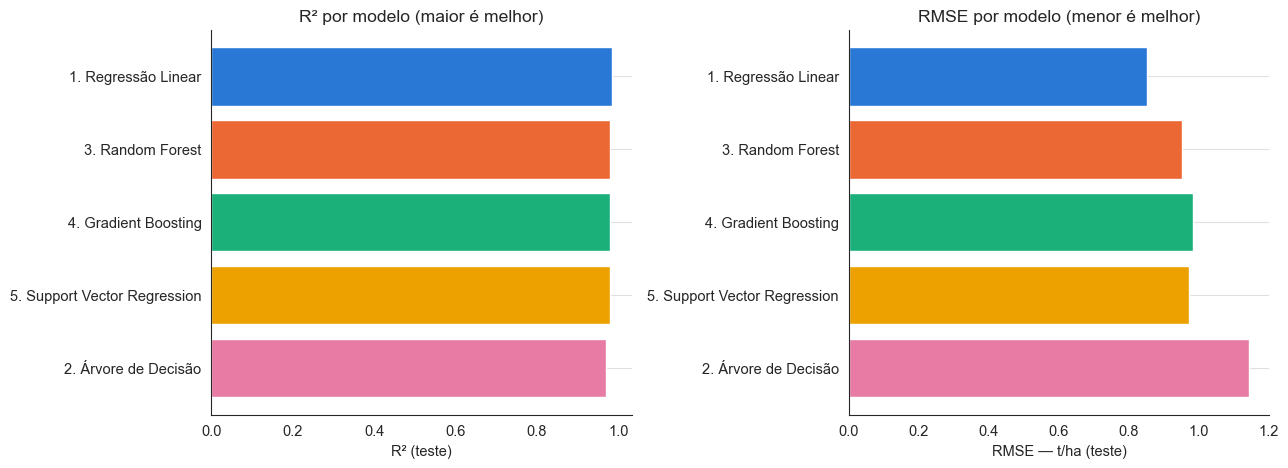

Melhor modelo (maior R² no teste): 1. Regressão Linear


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ordem = tabela_resultados["Modelo"]
axes[0].barh(ordem, tabela_resultados["R2"], color=CATEGORICAL[:len(ordem)])
axes[0].set_xlabel("R² (teste)")
axes[0].set_title("R² por modelo (maior é melhor)")
axes[0].invert_yaxis()
estilizar_eixos(axes[0])

axes[1].barh(ordem, tabela_resultados["RMSE"], color=CATEGORICAL[:len(ordem)])
axes[1].set_xlabel("RMSE — t/ha (teste)")
axes[1].set_title("RMSE por modelo (menor é melhor)")
axes[1].invert_yaxis()
estilizar_eixos(axes[1])

fig.tight_layout()
plt.show()

melhor_modelo_nome = tabela_resultados.iloc[0]["Modelo"]
print(f"Melhor modelo (maior R² no teste): {melhor_modelo_nome}")

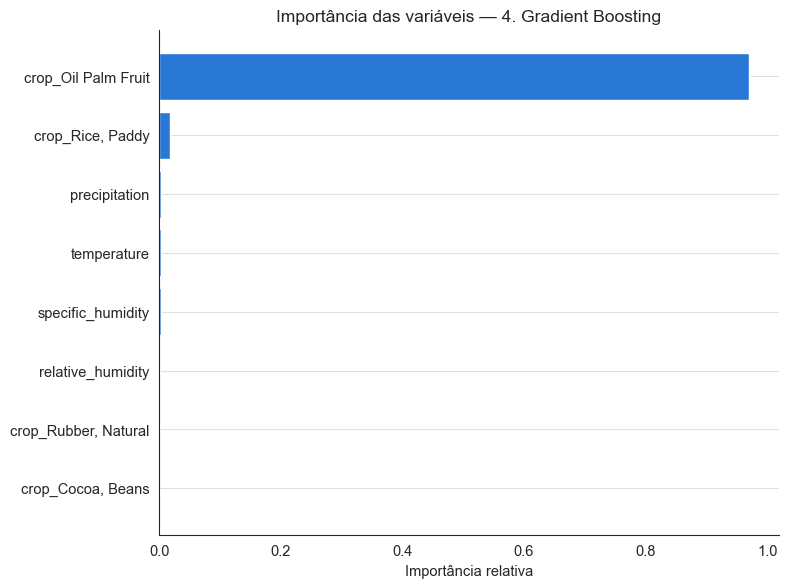

crop_Oil Palm Fruit     97.0%
crop_Rice, Paddy         1.8%
precipitation            0.4%
temperature              0.3%
specific_humidity        0.2%
relative_humidity        0.2%
crop_Rubber, Natural     0.0%
crop_Cocoa, Beans        0.0%
dtype: str


In [34]:
# Importância das variáveis, segundo o melhor modelo baseado em árvores disponível
nome_arvore = next((n for n in ["4. Gradient Boosting", "3. Random Forest", "2. Árvore de Decisão"] if n in modelos_treinados), None)
if nome_arvore:
    importancias = modelos_treinados[nome_arvore].named_steps["model"].feature_importances_
    serie_importancia = pd.Series(importancias, index=X.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(serie_importancia.index, serie_importancia.values, color=CATEGORICAL[0])
    ax.set_xlabel("Importância relativa")
    ax.set_title(f"Importância das variáveis — {nome_arvore}")
    estilizar_eixos(ax)
    plt.tight_layout()
    plt.show()

    print(serie_importancia.sort_values(ascending=False).map(lambda v: f"{v:.1%}"))

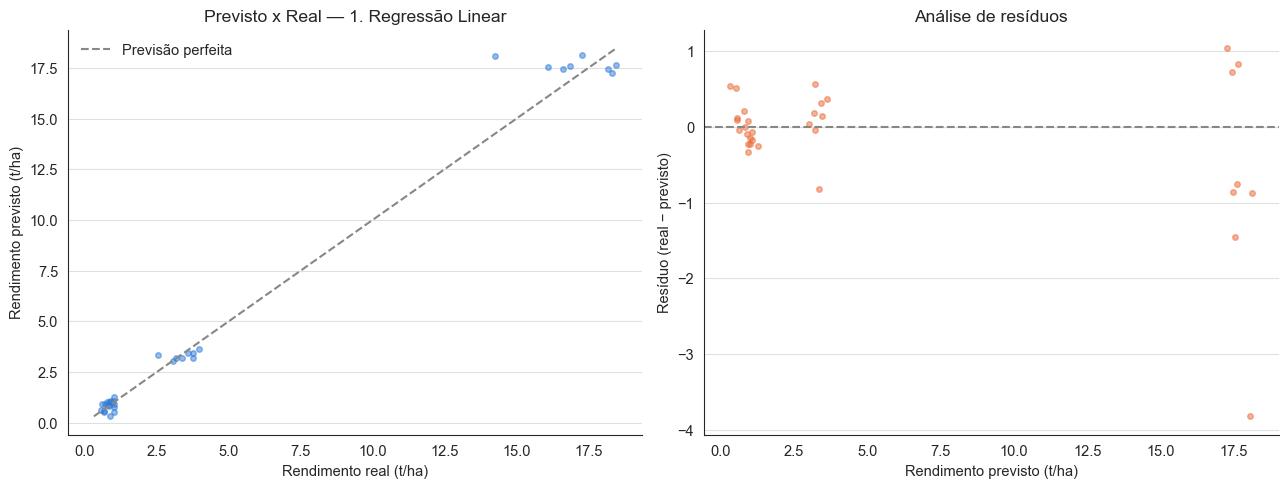

In [35]:
# Previsto x Real, e resíduos, para o melhor modelo
melhor_pipe = modelos_treinados[melhor_modelo_nome]
y_pred_melhor = melhor_pipe.predict(X_test)
residuos = y_test - y_pred_melhor

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_melhor, s=16, alpha=0.5, color=CATEGORICAL[0])
lim = [min(y_test.min(), y_pred_melhor.min()), max(y_test.max(), y_pred_melhor.max())]
axes[0].plot(lim, lim, "--", color=INK["muted"], linewidth=1.5, label="Previsão perfeita")
axes[0].set_xlabel("Rendimento real (t/ha)")
axes[0].set_ylabel("Rendimento previsto (t/ha)")
axes[0].set_title(f"Previsto x Real — {melhor_modelo_nome}")
axes[0].legend(frameon=False)
estilizar_eixos(axes[0])

axes[1].scatter(y_pred_melhor, residuos, s=16, alpha=0.5, color=CATEGORICAL[1])
axes[1].axhline(0, linestyle="--", color=INK["muted"], linewidth=1.5)
axes[1].set_xlabel("Rendimento previsto (t/ha)")
axes[1].set_ylabel("Resíduo (real − previsto)")
axes[1].set_title("Análise de resíduos")
estilizar_eixos(axes[1])

fig.tight_layout()
plt.show()

In [36]:
# Erro médio absoluto do melhor modelo, quebrado por cultura — o MAE agregado (tabela
# de resultados) pode esconder diferenças grandes entre culturas de escalas distintas
erro_por_cultura = pd.DataFrame({
    "crop": df.loc[y_test.index, "crop"],
    "erro_abs": (y_test - y_pred_melhor).abs(),
    "real": y_test,
})
erro_por_cultura["erro_pct"] = erro_por_cultura["erro_abs"] / erro_por_cultura["real"] * 100
erro_por_cultura.groupby("crop")[["erro_abs", "erro_pct"]].mean().round(2)

,erro_abs,erro_pct
crop,,
"Cocoa, Beans",0.13,15.50
Oil Palm Fruit,1.30,8.10
"Rice, Paddy",0.31,9.65
"Rubber, Natural",0.26,32.02


**Discussão dos modelos:**
- **A cultura (`crop`) domina a previsão.** O gráfico de importância acima mostra que
  a variável mais importante, isoladamente, é o indicador da cultura de maior escala
  (óleo de palma) — concentrando a esmagadora maioria da importância total, com as
  4 variáveis climáticas somadas contribuindo muito pouco. Combinado com as
  correlações fracas de clima x rendimento vistas na EDA para cacau/dendê, o quadro
  é consistente: **nesta base, saber qual cultura é explica a maior parte do
  rendimento; o clima ajusta detalhes dentro de cada cultura** (com destaque para o
  arroz, mais climaticamente sensível — Seção 3).
- **Por que a Regressão Linear ganhou:** como o efeito dominante (a cultura, via
  variáveis dummy) é bem separável de forma aditiva, e a contribuição do clima dentro
  de cada cultura é pequena e razoavelmente linear na janela observada, um modelo
  linear simples consegue capturar quase toda a estrutura dos dados — sem precisar de
  fronteiras de decisão complexas. Isso explica o R² de teste ligeiramente maior da
  Regressão Linear (0,984) sobre os ensembles baseados em árvore.
- **Mas olhando o MAE, o Random Forest é ligeiramente melhor** (erro absoluto médio
  menor) mesmo com R² um pouco inferior — sinal de que ele erra "menos feio" na
  maioria dos casos, mas tem alguns poucos erros maiores que penalizam o R² (métrica
  sensível a outliers, por ser baseada em erro ao quadrado). É um bom lembrete de
  olhar mais de uma métrica antes de eleger "o melhor modelo".
- **O erro por cultura** (tabela acima) confirma esse ponto na prática: o erro
  absoluto do dendê é o maior em valor bruto (~1,3 t/ha, esperado por sua escala
  ~10-20x maior), mas em termos **percentuais** é o dendê quem sai melhor (~8%) e a
  **borracha** quem sai pior (~32%) — mesmo com um erro absoluto pequeno (~0,26 t/ha),
  porque seu rendimento médio também é pequeno (<1 t/ha). É um exemplo concreto, com
  números desta própria execução, de por que MAE e MAPE podem discordar sobre "qual
  cultura o modelo acerta melhor".
- R² de teste e de validação cruzada ficaram próximos para a maioria dos modelos, o
  que é um bom sinal de estabilidade — mesmo com uma base pequena (156 registros,
  ~124 no treino), já que o padrão dominante (diferença entre culturas) é forte e
  fácil de aprender com poucos dados; a parte mais difícil de estimar com precisão é
  o ajuste fino dentro de cada cultura.
- O SVR com kernel RBF também captura não-linearidades, mas é mais sensível à escolha
  de hiperparâmetros (`C`, `epsilon`) e escala pior para bases muito grandes.
- O gráfico de resíduos permite checar se o erro do melhor modelo é homogêneo ao longo
  da faixa de rendimento, ou se cresce sistematicamente em algum extremo (o que
  sinalizaria heterocedasticidade e sugeriria investigar transformações da variável-alvo).

---
<a id="7"></a>
## 7. Conclusão

### Principais achados
- A base tem uma unidade de rendimento (`Yield`) consistente com **hg/ha** (padrão
  FAOSTAT), não t/ha como descrito no enunciado — convertemos para t/ha de forma
  transparente (Seção 2), e as 4 culturas (cacau, dendê, arroz e borracha) operam em
  escalas de rendimento muito diferentes entre si.
- As 4 variáveis climáticas são **idênticas entre culturas na mesma posição de linha**
  e variam em uma faixa estreita — evidência de que a base representa ~39 safras de
  um mesmo clima tropical estável aplicado às 4 culturas, e não fazendas/regiões
  climaticamente distintas.
- A correlação **global** entre clima e rendimento é praticamente nula, mas isso é um
  artefato da mistura de escalas entre culturas: a correlação **por cultura** revela
  que o arroz é claramente sensível ao clima nesta amostra, enquanto cacau e dendê
  quase não são, dentro da janela climática observada.
- A clusterização (K-Means, validada por silhueta e visualizada via PCA) produziu
  grupos **perfeitamente equilibrados entre as 4 culturas** — uma consequência direta
  da estrutura da base — confirmando que os clusters capturam exclusivamente padrões
  climáticos (por safra), nunca a cultura. O DBSCAN não encontrou "vales" de
  densidade fortes, reforçando que a variação climática aqui é contínua e suave.
- Isolation Forest e IQR por cultura sinalizaram um pequeno conjunto de registros
  discrepantes (a IQR por cultura, com N pequeno por grupo, foi mais conservadora e
  não sinalizou nenhum; o Isolation Forest, multivariado, sinalizou ~3%).
- Dentre os cinco algoritmos de regressão testados, todos atingiram R² acima de 0,97
  no teste — a Regressão Linear teve o maior R² (0,984), enquanto o Random Forest
  teve o menor MAE; a variável de maior importância, disparado, é o indicador da
  cultura de maior escala (dendê/óleo de palma), confirmando que **a cultura plantada
  explica a maior parte do rendimento nesta base**, com o clima refinando o resultado
  dentro de cada cultura.

### Pontos fortes do trabalho
- Pipeline de ponta a ponta (limpeza → EDA → outliers → clusterização → modelagem)
  documentado e reprodutível, com sementes aleatórias fixas;
- Pré-processamento sem vazamento de dados (padronização ajustada somente no treino,
  dentro de um `Pipeline` do scikit-learn);
- Comparação justa entre 5 famílias de algoritmos distintas (linear, árvore única,
  dois ensembles e kernel), com as mesmas métricas e validação cruzada;
- Detecção de outliers por múltiplos métodos independentes, aumentando a confiança
  nos pontos sinalizados;
- Carga de dados defensiva (nomes de coluna reconhecidos por padrão, não por posição
  fixa), tornando o notebook resiliente a pequenas variações no arquivo de origem.

### Limitações
- **Base pequena:** apenas 156 registros (39 por cultura, 4 culturas), o que limita a
  robustez estatística dos modelos e a estabilidade da validação cruzada;
- **Pseudo-replicação climática:** as 4 variáveis climáticas são idênticas entre as
  4 culturas na mesma posição de linha — ou seja, existem apenas **~39 observações
  climáticas realmente independentes**, não 156. Isso não invalida a modelagem (o
  rendimento de cada cultura é, de fato, uma observação independente), mas significa
  que a variabilidade climática coberta pela base é menor do que o total de linhas
  sugere;
- O modelo usa apenas 4 variáveis agrometeorológicas; fatores conhecidos por afetar o
  rendimento agrícola — tipo de solo, pH, adubação, disponibilidade de irrigação,
  incidência de pragas/doenças e práticas de manejo — não estão presentes na base e
  poderiam melhorar substancialmente a capacidade preditiva;
- Não há um ano-calendário explícito (apenas a ordem das linhas no arquivo), o que
  permite ver a **variação relativa** do rendimento ao longo das safras (Seção 3), mas
  não relacioná-la a anos específicos ou eventos externos conhecidos;
- Apenas 4 culturas estão representadas, todas de clima tropical úmido — o modelo não
  deve ser extrapolado para culturas de clima temperado ou semiárido sem novos dados;
- O SVR e o Gradient Boosting exigem ajuste fino de hiperparâmetros (aqui usados com
  valores razoáveis, mas não otimizados via `GridSearchCV`/`RandomizedSearchCV`) —
  uma busca sistemática de hiperparâmetros é um próximo passo natural;
- Outliers foram sinalizados, mas não removidos nem validados em campo — a decisão de
  tratá-los como erro de sensor ou evento real requer conhecimento agronômico que foge
  ao escopo estatístico deste notebook.

### Próximos passos sugeridos
- Ampliar a base com mais safras e, principalmente, com **mais variação climática**
  (diferentes regiões/anos atípicos) — a janela climática estreita observada aqui é a
  principal limitante para medir o efeito real do clima sobre o rendimento;
- Buscar hiperparâmetros ótimos (`GridSearchCV`) para os modelos de melhor desempenho;
- Incorporar dados de solo e manejo, se disponíveis, para reduzir o erro residual;
- Reavaliar o modelo periodicamente à medida que novas safras forem coletadas
  (re-treino contínuo), especialmente após hospedar a solução na nuvem (ver Entrega 2,
  no README do repositório).

---
### Referências
- Material de aula — Capítulo 13, *Modelagem de Dados com Regressão Supervisionada* (Fase 4).
- Material de aula — Capítulo 10, *Machine Learning Sem Supervisão: Uma Jornada pela Descoberta de Dados* (Fase 5).
- Documentação oficial do [scikit-learn](https://scikit-learn.org/stable/).